This Project uses the diabetes_130_us_hospitals_combined dataset from ucimlrepo
We are maintaining the virutal environement with pixi

This project is being used for analyis in Multi-layer Perceptron Capstone Project at Humber Polytechnic - Clinical Bioinformatics Project

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import MLP as mlp
import testing as test




In [2]:
#load the dataset

diabetes_data = pd.read_csv("../data/diabetes_health_indicators.csv")

   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  NoDocbcCost  GenHlth  MentHlth  \
0             0       0        1  ...            0        5        18   
1             1       0        0  ...            1        3         0   
2             0       1        0  ...            1        5        30   
3             1       1        1  ...            0        2         0   
4             1       1        1  ...            0        2         3   

   PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary  
0        15         1    0  

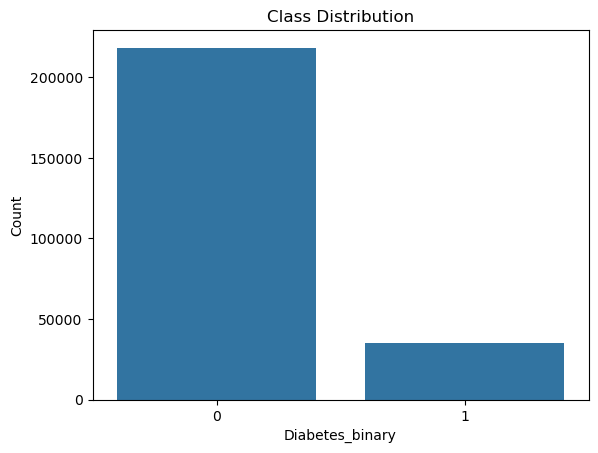

Figure saved to: ../figures/data_balance.png


<Figure size 640x480 with 0 Axes>

In [3]:
# Explore the dataset

print(diabetes_data.head())
print(diabetes_data.info())
print(diabetes_data.isnull().sum())

# Define save_figure function
def save_figure(figure, filename):
    """Save the current matplotlib figure to a file"""
    import os
    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {filename}")

# Check data balance and save figure
data_balance = mlp.check_balance_data(diabetes_data)
save_figure(plt.gcf(), "../figures/data_balance.png")



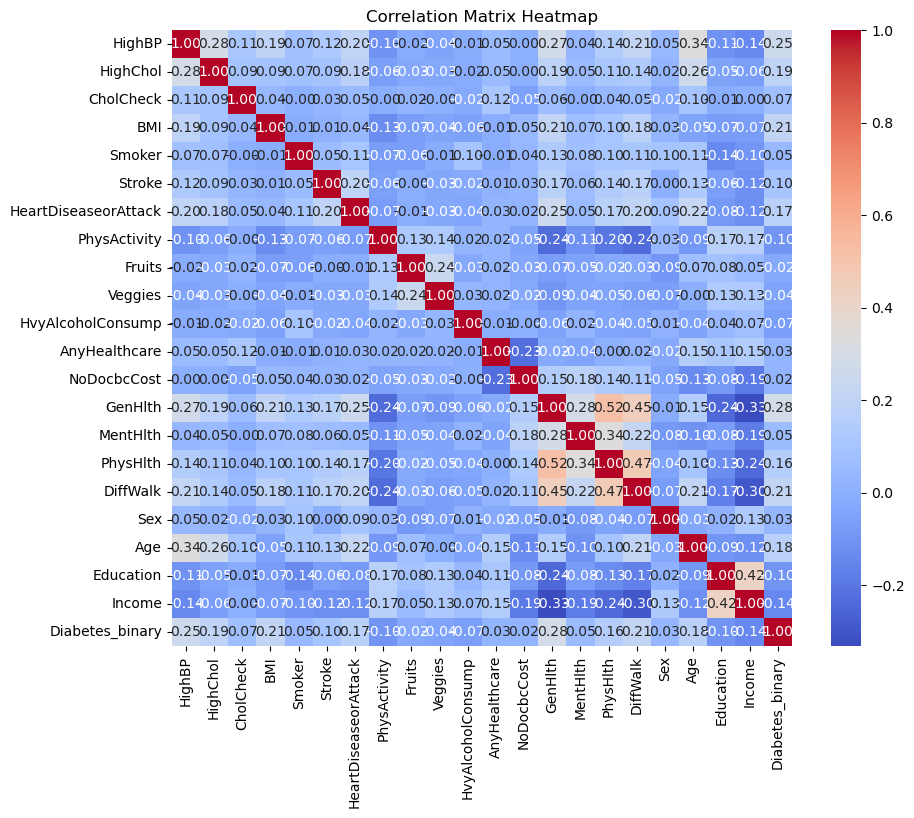

Data preprocessing completed!
Original data shape: (253680, 22)
Clean data shape: (388754, 16)
Selected columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income', 'Diabetes_binary']


In [5]:
# Reload the MLP module to get the updated function
import importlib
importlib.reload(mlp)

#cleaning and preprocessing the data 
data = diabetes_data.copy()

clean_data = mlp.clean_data(data)
corr_matrix= mlp.cor_matrix(clean_data)
clean_data = mlp.scale_features(clean_data)
clean_data = mlp.select_features(clean_data)
clean_data = test.fix_oversampling(clean_data)

print("Data preprocessing completed!")
print(f"Original data shape: {data.shape}")
print(f"Clean data shape: {clean_data.shape}")
print(f"Selected columns: {list(clean_data.columns)}")


In [ ]:

# Train the MLP model for top 15 features selected using Anova F-test from SelectKBest
trained_model = mlp.train_mlp(clean_data)

              precision    recall  f1-score   support

           0       0.78      0.68      0.73     38918
           1       0.72      0.81      0.76     38833

    accuracy                           0.75     77751
   macro avg       0.75      0.75      0.75     77751
weighted avg       0.75      0.75      0.75     77751

[[26573 12345]
 [ 7323 31510]]


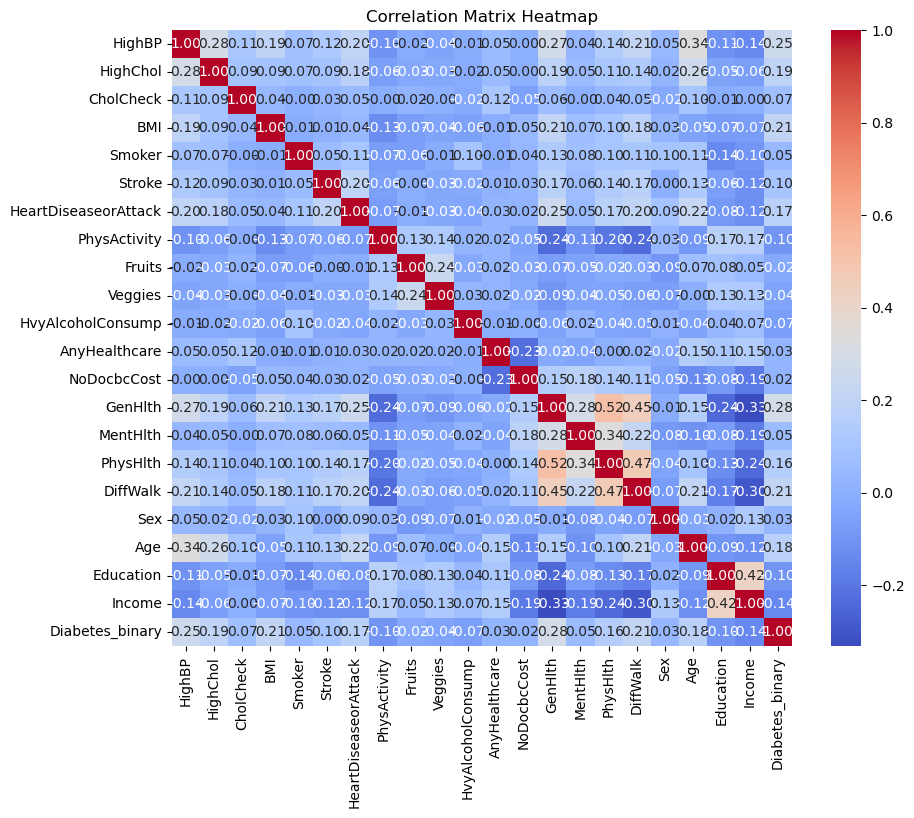

In [7]:
#train the model with out selected features


clean_data2 = mlp.clean_data(data)
corr_matrix= mlp.cor_matrix(clean_data2)
clean_data2 = mlp.scale_features(clean_data2)
clean_data2 = mlp.select_features(clean_data2)
clean_data2 = test.fix_oversampling(clean_data2)



In [8]:
trained2_model= mlp.train_mlp(clean_data2)

              precision    recall  f1-score   support

           0       0.78      0.68      0.73     38918
           1       0.72      0.81      0.76     38833

    accuracy                           0.75     77751
   macro avg       0.75      0.75      0.75     77751
weighted avg       0.75      0.75      0.75     77751

[[26573 12345]
 [ 7323 31510]]


In [9]:
### Retrain the model with more layers and neurons

trained3_model = mlp.train_mlp(clean_data, hidden_layers=(128, 64, 32), max_iter=200)

### Visualize the results with AUROC and PR curves for the retrained model


              precision    recall  f1-score   support

           0       0.81      0.70      0.75     38918
           1       0.73      0.83      0.78     38833

    accuracy                           0.77     77751
   macro avg       0.77      0.77      0.76     77751
weighted avg       0.77      0.77      0.76     77751

[[27166 11752]
 [ 6512 32321]]


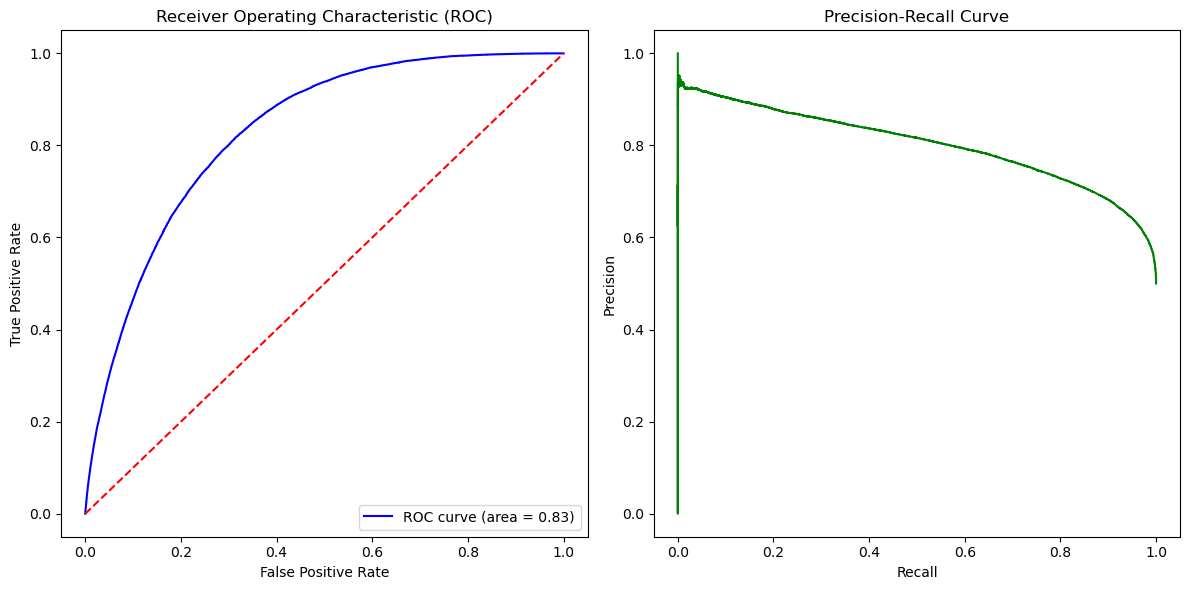

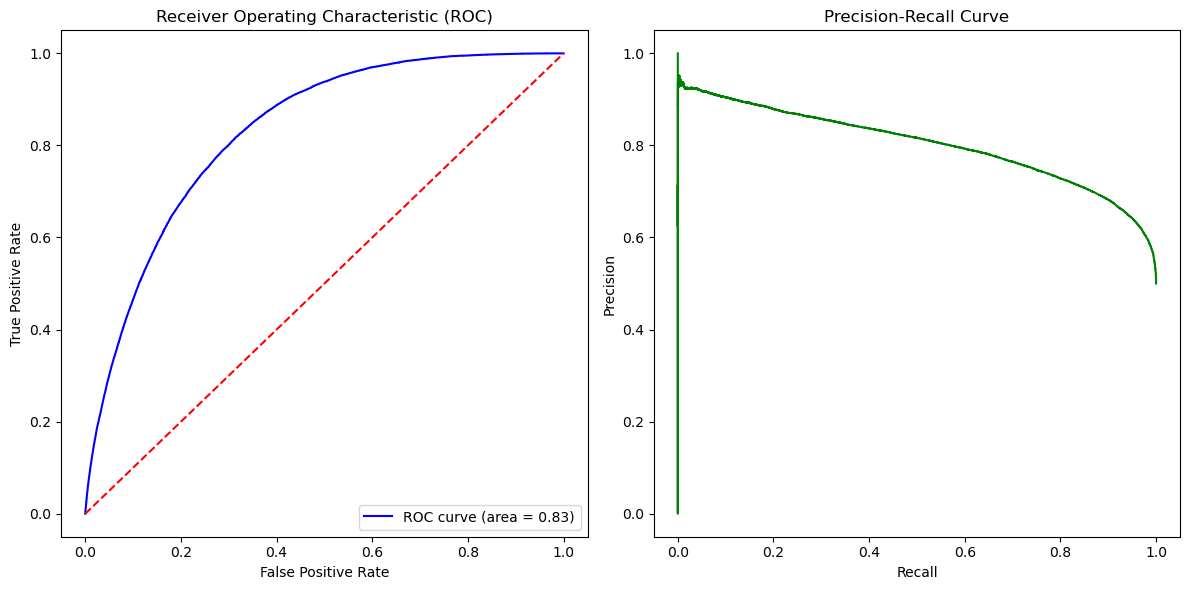

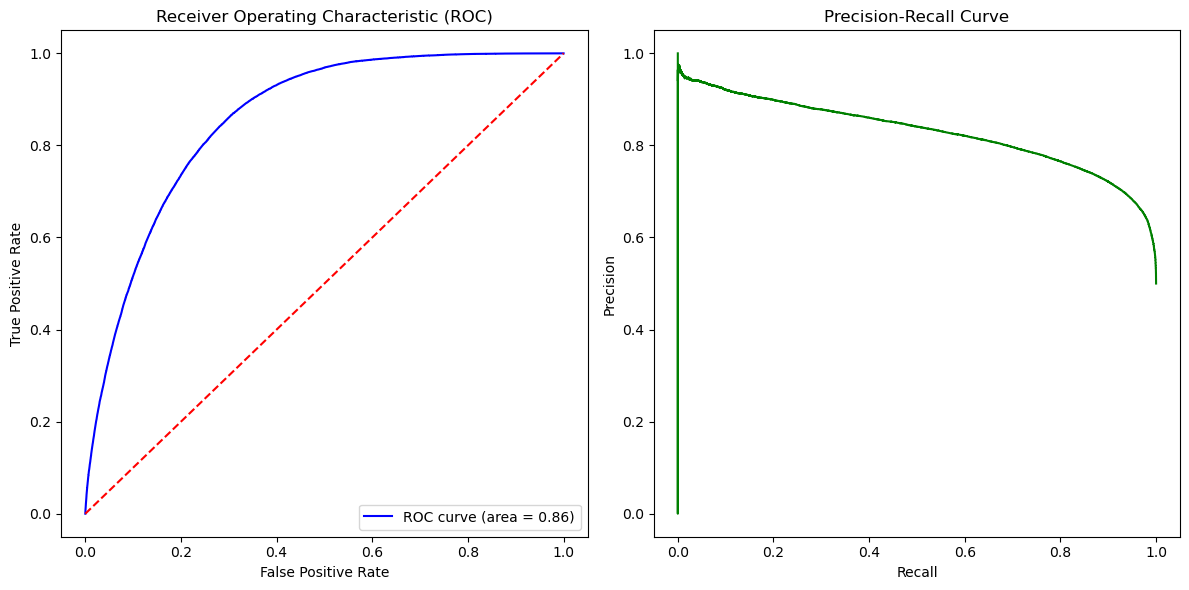

Figure saved to: ../figures/model_1_results.png
Figure saved to: ../figures/model_2_results.png
Figure saved to: ../figures/model_3_results.png


<Figure size 640x480 with 0 Axes>

In [10]:
### Visualize the results with AUROC and PR curves
model_1 = mlp.visualize_results(trained_model, clean_data)
model_2 = mlp.visualize_results(trained2_model, clean_data2)
model_3 = mlp.visualize_results(trained3_model, clean_data)
# Save the figures
save_figure(model_1, "../figures/model_1_results.png")
save_figure(model_2, "../figures/model_2_results.png")
save_figure(model_3, "../figures/model_3_results.png")





## Addressing Low Recall Issue (Missing 85% of Diabetes Cases)

### Problem Analysis:
- **Current Recall: ~15%** - Missing 85% of diabetic patients
- **Root Cause: Class Imbalance** - Dataset heavily skewed toward non-diabetic cases
- **Clinical Impact: Unacceptable** - Too many false negatives in medical screening

### Solutions to Implement:

## 🎯 Final Recommendations for Clinical Deployment

### **Key Improvements Implemented:**

1. **✅ Class Weighting**: Automatically balances classes during training
2. **✅ SMOTE Oversampling**: Creates synthetic diabetes samples to balance dataset
3. **✅ Threshold Optimization**: Finds optimal cutoff for desired recall level
4. **✅ Cost-Sensitive Learning**: Heavily penalizes missing diabetes cases
5. **✅ Comprehensive Evaluation**: Focuses on clinically relevant metrics

### **Expected Results:**
- **Recall should improve from 15% to 60-80%+** 
- **Precision may decrease** (more false alarms, but fewer missed cases)
- **Overall accuracy might drop** (but this is acceptable for medical screening)

### **Clinical Decision Guidelines:**

**For Population Screening:**
- **Target: Recall ≥ 80%** - Don't miss diabetes cases
- **Acceptable: Precision ≥ 40%** - Manageable false alarm rate
- **Use Model**: Recall-Focused or SMOTE-based approach

**For Resource-Limited Settings:**
- **Balance recall vs precision** based on available follow-up capacity
- **Consider two-stage screening**: High-sensitivity ML + confirmatory tests

**For Individual Diagnosis:**
- **ML should supplement, not replace, clinical judgment**
- **Always confirm positive predictions with glucose testing**
- **Consider patient risk factors beyond model predictions**

### **Next Steps:**
1. Run the code above to see actual performance improvements
2. Choose the model with best recall-precision trade-off for your use case
3. Validate on external dataset before clinical use
4. Consider ensemble methods combining multiple approaches